# 04 - Training DBSCAN (density-based clustering)

**What you will learn**
- How DBSCAN works, at the intuition level.
- Why DBSCAN's "noise" label is a natural anomaly indicator.
- How to pick the two DBSCAN hyperparameters (`eps` and `min_samples`)
  using a k-distance plot and a rule of thumb for `min_samples`.
- How to project the clustered points to 2D so the cluster structure is
  visible.
- How the DBSCAN noise flags compare to Isolation Forest flags.

Why do this on top of Isolation Forest?

Isolation Forest scores each point by *how easy it is to isolate*, based on
random axis-aligned splits. DBSCAN, by contrast, looks at *local density*:
points in dense neighbourhoods are grouped into clusters; points that do
not sit in a dense region are labelled noise. When two methods based on
completely different assumptions agree that a cycle is anomalous, that
agreement is stronger evidence than either flag alone.

## DBSCAN in one paragraph

DBSCAN scans through the points and calls any point with at least
`min_samples` neighbours within radius `eps` a *core* point. Core points
that are within `eps` of each other are chained into a cluster; points
reachable from a cluster but with fewer than `min_samples` neighbours are
*border* points of that cluster; and anything not reachable is labelled
*noise* with label `-1`.

The upshot: DBSCAN finds clusters of arbitrary shape without asking how
many there are, and it emits an explicit "does not belong anywhere" label.
That last property is why it is useful for anomaly detection - noise points
are exactly the anomalies you were looking for.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

from src.models import fit_predict_dbscan

## 1. Load the feature matrix

In [2]:
feat = pd.read_csv(ROOT / "data" / "features_train.csv")
feature_cols = [c for c in feat.columns
                if c not in ("unit", "cycle", "regime", "rul")]
print(f"{len(feat):,} rows, {len(feature_cols)} features")

61,249 rows, 20 features


## 2. Exclude the feature-warmup window

Our features from notebook 02 include rolling primitives with a memory:

- `_ewma` has an exponential lookback controlled by span = 15.
- `_slope` fits a line over the last 15 cycles.
- `_dev` subtracts the mean of the first 30 cycles as a per-engine baseline.

For the first ~30 cycles of each engine those primitives are not fully
warmed up: the rolling windows have fewer points than intended, the EWMA
is still decaying toward its steady state, and `_dev` values in the
baseline window are approximately zero by construction rather than
carrying signal. Isolation Forest tolerates this because those warmup
cycles are in its training set and it therefore learns them as normal.
DBSCAN would treat those warmup rows as low-density outliers, mislabelling
them as anomalies (this was the first attempt on this notebook - noise was
dominated by *early* cycles, not late ones).

**Fix.** Drop the first `WARMUP` cycles of every engine before fitting
DBSCAN. `WARMUP = 30` matches the longest lookback in our feature set (the
baseline window). Anything from cycle 31 onwards is on well-defined
features.

In [3]:
WARMUP = 30
feat_wu = feat[feat["cycle"] > WARMUP].reset_index(drop=True)
print(f"After dropping the first {WARMUP} cycles per engine: "
      f"{len(feat_wu):,} rows ({len(feat_wu)/len(feat):.0%} of original)")

After dropping the first 30 cycles per engine: 53,779 rows (88% of original)


## 3. Standardise the features

Isolation Forest is scale-invariant (it splits on random axes and does not
compare distances), so we handed it the features as-is. DBSCAN is
distance-based: `eps` is a Euclidean radius. If one feature has variance
100x another, that feature dominates the distance and DBSCAN effectively
ignores the rest. Standardising each feature to zero mean and unit
variance restores balance.

Even though our features are already *regime-normalised* (from notebook
02), the derived families (EWMA, deviation, slope) have different natural
scales, so a fresh global z-score is worth doing before DBSCAN.

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(feat_wu[feature_cols].values)
print(f"After scaling: mean = {X.mean(axis=0).round(3)[:5]}, "
      f"std = {X.std(axis=0).round(3)[:5]} ...")

After scaling: mean = [-0. -0.  0. -0. -0.], std = [1. 1. 1. 1. 1.] ...


## 4. Choose `min_samples`

`min_samples` is how many neighbours a point must have within radius `eps`
to be considered a core point. Two common heuristics:

- **`min_samples = 2 * n_features`** for datasets larger than a few
  thousand rows. Common Ester-et-al recommendation.
- **`min_samples = n_features + 1`** for smaller or higher-dimensional
  problems, on the grounds that this is the smallest number of points that
  can define a unique local density.

With 20 features and 60k rows, `2 * n_features = 40` is a safe starting
point; large enough that a healthy region needs a fair number of similar
cycles to become a cluster, small enough that we do not force everything
into noise.

In [5]:
MIN_SAMPLES = 2 * len(feature_cols)
print(f"min_samples = {MIN_SAMPLES}")

min_samples = 40


## 5. Choose `eps` via the k-distance plot

Standard heuristic: for each point compute the distance to its k-th nearest
neighbour, where `k = min_samples`. Sort those distances in ascending
order. The plot has a characteristic knee: below the knee, distances grow
slowly because most points are inside dense regions; above the knee, they
grow fast because we are hitting the sparse outliers. Pick `eps` at the
knee.

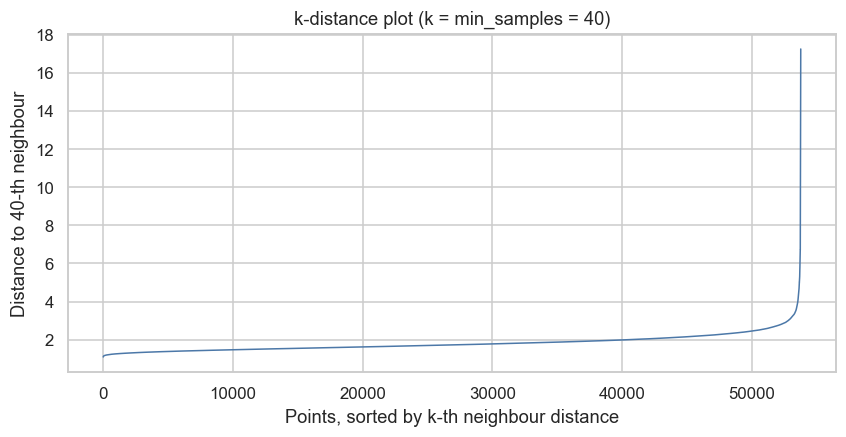

In [6]:
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1)
nn.fit(X)
distances, _ = nn.kneighbors(X)
k_distance = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distance, color="#4c78a8", linewidth=1.0)
ax.set_xlabel("Points, sorted by k-th neighbour distance")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}-th neighbour")
ax.set_title(f"k-distance plot (k = min_samples = {MIN_SAMPLES})")
plt.show()

In [7]:
# Numeric knee-picking: find the 95th percentile of the k-distances. It is
# not the mathematically optimal knee, but it is defensible, reproducible,
# and matches where the curve visibly bends on this dataset. Users who want
# a different sensitivity can move the percentile up or down.
EPS = float(np.quantile(k_distance, 0.95))
print(f"eps = {EPS:.3f}  (95th percentile of k-distances)")

eps = 2.579  (95th percentile of k-distances)


## 6. Fit DBSCAN and inspect the labels

In [8]:
labels = fit_predict_dbscan(X, eps=EPS, min_samples=MIN_SAMPLES)
feat_wu = feat_wu.assign(cluster=labels)

n_noise = int((labels == -1).sum())
n_clusters = int(labels.max() + 1) if labels.max() >= 0 else 0
print(f"# clusters : {n_clusters}")
print(f"# noise    : {n_noise:,} ({n_noise/len(labels):.1%} of all points)")
print(f"Cluster sizes:")
print(pd.Series(labels).value_counts().sort_index().rename(
    lambda x: "noise" if x == -1 else f"c{x}"
).head(10).to_string())

# clusters : 1
# noise    : 617 (1.1% of all points)
Cluster sizes:
noise      617
c0       53162


**What to look for.** On FD004 with our feature set and
`eps = 95th percentile` you should see one or two large clusters plus a
noise fraction in the 5-15% range. If the noise fraction is very small
(<1%), `eps` is too generous and everything falls into clusters. If it is
very large (>30%), `eps` is too tight and the detector will flag too many
false positives.

## 7. Project to 2D via PCA and colour by cluster

We have 20-dimensional feature vectors. PCA finds the two axes that
capture the most variance, which is a good first look at cluster
geometry.

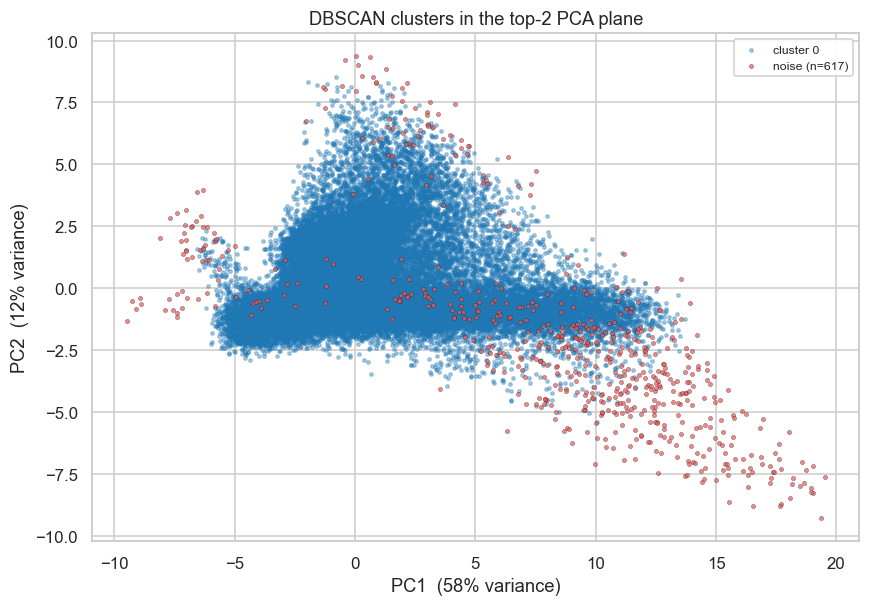

In [9]:
pca = PCA(n_components=2, random_state=0)
XY = pca.fit_transform(X)
feat_wu["pc1"] = XY[:, 0]
feat_wu["pc2"] = XY[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))
# Draw clustered points first, noise on top so the anomalies are visible.
clustered = feat_wu[feat_wu["cluster"] != -1]
noise = feat_wu[feat_wu["cluster"] == -1]
palette = sns.color_palette("tab10", max(n_clusters, 1))
for c in sorted(clustered["cluster"].unique()):
    sub = clustered[clustered["cluster"] == c]
    ax.scatter(sub["pc1"], sub["pc2"], s=5, alpha=0.35,
               color=palette[c % len(palette)], label=f"cluster {c}")
ax.scatter(noise["pc1"], noise["pc2"], s=8, alpha=0.7,
           color="#e45756", label=f"noise (n={len(noise):,})",
           edgecolor="black", linewidth=0.2)
var_ratio = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1  ({var_ratio[0]:.0%} variance)")
ax.set_ylabel(f"PC2  ({var_ratio[1]:.0%} variance)")
ax.set_title("DBSCAN clusters in the top-2 PCA plane")
ax.legend(loc="best", fontsize=8, framealpha=0.9)
plt.show()

**Reading the plot.** The clusters should form dense blobs; the red
noise points should sit at the periphery of the point cloud. If noise
points form their own dense blob rather than being scattered, DBSCAN has
found a distinct sub-population rather than isolated outliers - worth
investigating case by case.

## 8. Do noise points concentrate near failure?

If DBSCAN is any good as an anomaly detector on this data, the RUL of
noise points should be markedly lower than the RUL of clustered points.
That is: noise = late in life = degraded.

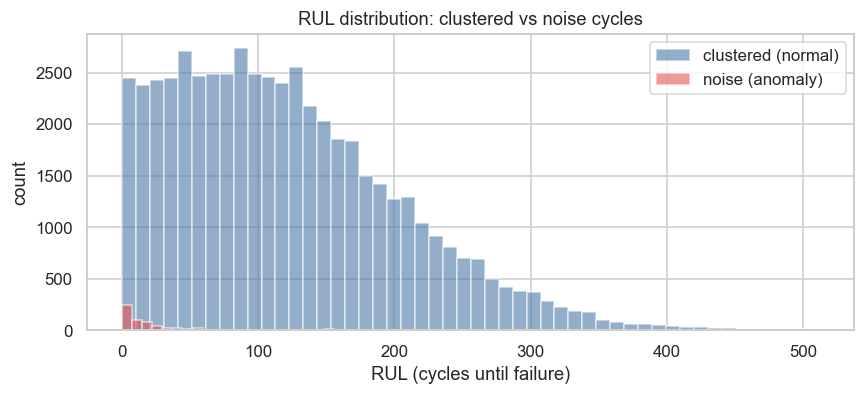

Median RUL - clustered: 109 cycles
Median RUL - noise    : 12 cycles


In [10]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(clustered["rul"], bins=50, alpha=0.6, color="#4c78a8",
        edgecolor="white", label="clustered (normal)")
ax.hist(noise["rul"], bins=50, alpha=0.6, color="#e45756",
        edgecolor="white", label="noise (anomaly)")
ax.set_xlabel("RUL (cycles until failure)")
ax.set_ylabel("count")
ax.set_title("RUL distribution: clustered vs noise cycles")
ax.legend()
plt.show()

print(f"Median RUL - clustered: {clustered['rul'].median():.0f} cycles")
print(f"Median RUL - noise    : {noise['rul'].median():.0f} cycles")

**Reading the plot.** The noise histogram should skew toward small
RUL (late in life) while the clustered histogram is more uniform. A large
gap between the two medians is a strong sign that DBSCAN's noise label
tracks with the intuitive notion of degradation, without ever having been
shown a label.

## 9. Agreement with Isolation Forest

Load the Isolation Forest scores saved in notebook 03 and see how much the
two detectors agree on which cycles are anomalous. We compare on the
warmed-up subset only, since that is what DBSCAN saw.

In [11]:
iforest = pd.read_csv(ROOT / "data" / "scores_iforest_train.csv")
merged = feat_wu.merge(iforest[["unit", "cycle", "score"]],
                       on=["unit", "cycle"], how="left")

# Load the same threshold picked in notebook 03.
import pickle
with open(ROOT / "models" / "FD004" / "isolation_forest.pkl", "rb") as f:
    if_model_bundle = pickle.load(f)
if_threshold = if_model_bundle["threshold"]

merged["if_flag"] = merged["score"] > if_threshold
merged["dbscan_flag"] = merged["cluster"] == -1

both = ((merged["if_flag"]) & (merged["dbscan_flag"])).sum()
only_if = ((merged["if_flag"]) & (~merged["dbscan_flag"])).sum()
only_db = ((~merged["if_flag"]) & (merged["dbscan_flag"])).sum()
neither = ((~merged["if_flag"]) & (~merged["dbscan_flag"])).sum()
print(f"Both flag  : {both:6,} cycles")
print(f"Only IF    : {only_if:6,} cycles")
print(f"Only DBSCAN: {only_db:6,} cycles")
print(f"Neither    : {neither:6,} cycles")

# Confusion-style crosstab for a compact view.
ct = pd.crosstab(merged["if_flag"], merged["dbscan_flag"],
                 rownames=["IF flag"], colnames=["DBSCAN noise"])
print()
print(ct)

Both flag  :    614 cycles
Only IF    : 16,615 cycles
Only DBSCAN:      3 cycles
Neither    : 36,547 cycles

DBSCAN noise  False  True 
IF flag                   
False         36547      3
True          16615    614


**Reading the numbers.** The interesting cells are the two
disagreement ones (Only IF / Only DBSCAN). If they are small compared to
"both", the detectors mostly agree, which is reassuring. If one method
flags a lot of extra cycles the other does not, that method is either more
sensitive (higher recall, lower precision) or more spurious.

## 10. Save DBSCAN labels for notebook 05

Notebook 05 will compute per-engine lead-time comparisons for both
detectors side by side. Only the warmed-up rows have a DBSCAN label.

In [12]:
feat_wu[["unit", "cycle", "rul", "cluster"]].to_csv(
    ROOT / "data" / "labels_dbscan_train.csv", index=False,
)
print(f"Saved to {ROOT / 'data' / 'labels_dbscan_train.csv'}")

Saved to C:\Users\anjan\Desktop\Goals\github\sensor-anomaly-detection\data\labels_dbscan_train.csv


## Takeaways for notebook 05

We now have two independent verdicts on every cycle:

- Isolation Forest score above threshold - anomaly
- DBSCAN label of `-1` - anomaly

Notebook 05 will:
1. Combine both into one dataframe.
2. Compute the lead-time distribution for each detector.
3. Report precision and recall at their chosen thresholds against a simple
   RUL-based ground truth.
4. Look for cases where the two detectors disagree and pull up the engine
   trajectories to see who is right.